In [1]:
import rdata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# --- 1. CARGAR LOS DATOS CON RDATA ---
# Parsear y convertir el archivo RData
parsed = rdata.parser.parse_file('listings.RData')
converted = rdata.conversion.convert(parsed)

In [44]:
df = converted['listings'] # Aquí es donde se define 'df'
print(df.columns.tolist())

[np.str_('id'), np.str_('listing_url'), np.str_('scrape_id'), np.str_('last_scraped'), np.str_('source'), np.str_('name'), np.str_('description'), np.str_('neighborhood_overview'), np.str_('picture_url'), np.str_('host_id'), np.str_('host_url'), np.str_('host_name'), np.str_('host_since'), np.str_('host_location'), np.str_('host_about'), np.str_('host_response_time'), np.str_('host_response_rate'), np.str_('host_acceptance_rate'), np.str_('host_is_superhost'), np.str_('host_thumbnail_url'), np.str_('host_picture_url'), np.str_('host_neighbourhood'), np.str_('host_listings_count'), np.str_('host_total_listings_count'), np.str_('host_verifications'), np.str_('host_has_profile_pic'), np.str_('host_identity_verified'), np.str_('neighbourhood'), np.str_('neighbourhood_cleansed'), np.str_('neighbourhood_group_cleansed'), np.str_('latitude'), np.str_('longitude'), np.str_('property_type'), np.str_('room_type'), np.str_('accommodates'), np.str_('bathrooms'), np.str_('bathrooms_text'), np.str_(

In [45]:

# Limpiar la columna price
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)

# Convertir a número
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Ahora sí volvemos a generar num_vars (incluyendo el precio ya corregido)
num_vars = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).dropna()

In [46]:
print(df['price'].head())
print(df['price'].describe())
print("Cantidad de NaN:", df['price'].isna().sum())

1     97.0
2    160.0
3     38.0
4    145.0
5     58.0
Name: price, dtype: Float64
count        76246.0
mean       750.50922
std      4250.606945
min              8.0
25%            120.0
50%            193.0
75%            326.0
max          50123.0
Name: price, dtype: Float64
Cantidad de NaN: 95502


In [ ]:
print("Objetos en el RData:", converted.keys())
# Asignar el dataframe

# Ver estructura para tu diccionario de variables
print("\n--- Información del Dataset ---")
df.info()

Objetos en el RData: dict_keys(['listings'])

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171748 entries, 1 to 171748
Data columns (total 80 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            171748 non-null  float64
 1   listing_url                                   171748 non-null  string 
 2   scrape_id                                     171748 non-null  float64
 3   last_scraped                                  171748 non-null  string 
 4   source                                        171748 non-null  string 
 5   name                                          171748 non-null  string 
 6   description                                   171748 non-null  string 
 7   neighborhood_overview                         171748 non-null  string 
 8   picture_url                                   

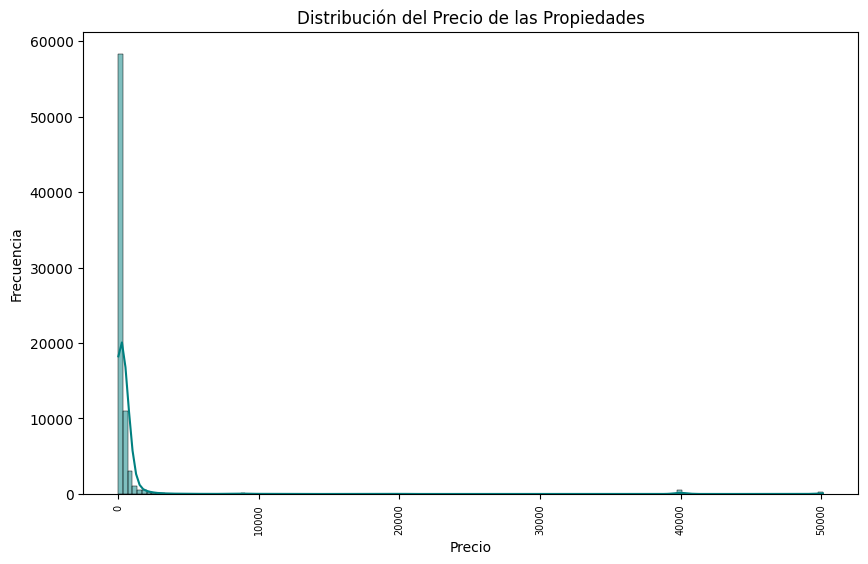

In [37]:
# --- 2. ANÁLISIS EXPLORATORIO: Distribución del precio ---
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].dropna(), bins=150, kde=True, color='teal')
plt.title('Distribución del Precio de las Propiedades')
plt.xlabel('Precio')
plt.xticks(rotation=90,fontsize=7)
plt.ylabel('Frecuencia')
plt.show()

La distribución del precio de las propiedades presenta una clara asimetría positiva (sesgo hacia la derecha). Esto indica que la gran mayoría de las viviendas de SmartStay Advisors se concentran en un rango de precios bajos a moderados. Sin embargo, la larga cola hacia la derecha revela la presencia de valores atípicos (outliers); es decir, un grupo reducido de propiedades de lujo o con alta capacidad que tienen precios significativamente más altos que el resto.

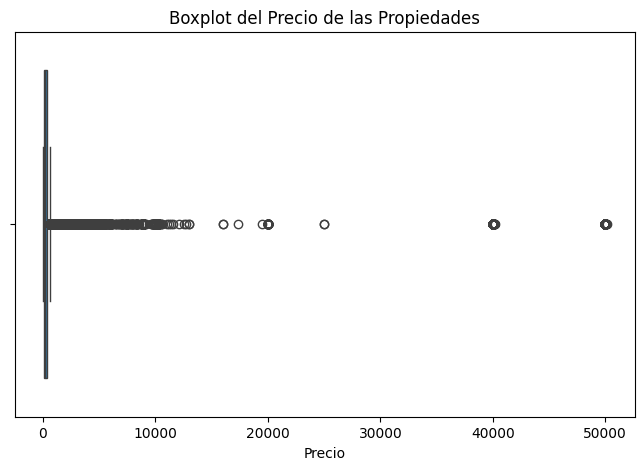

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title('Boxplot del Precio de las Propiedades')
plt.xlabel('Precio')
plt.show()

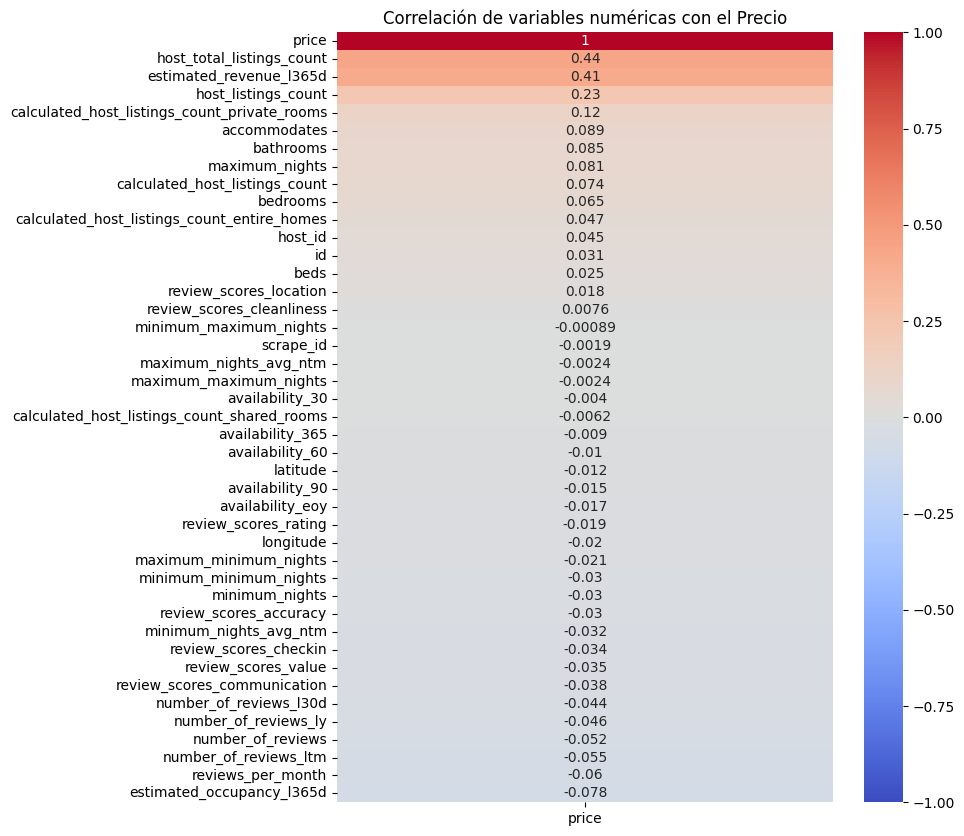

In [49]:
##--- 3. ANÁLISIS DE RELACIONES (Con la variable respuesta: precio) ---
# Extraer numéricas y quitar NAs temporalmente para la matriz
num_vars = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).dropna()

plt.figure(figsize=(8, 10))
# Enfocarnos solo en qué afecta al precio
correlacion_precio = num_vars.corr()[['price']].sort_values(by='price', ascending=False)
sns.heatmap(correlacion_precio, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de variables numéricas con el Precio')
plt.show()


In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 4. ANÁLISIS DE GRUPOS (Clustering K-Means) ---
# 1. Escalar los datos 
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(num_vars)

# 2. Agrupamos en 3 perfiles
kmeans = KMeans(n_clusters=3, random_state=42)
num_vars['cluster'] = kmeans.fit_predict(datos_escalados)

# 3. Mostrar características promedio de los grupos
print("\n--- Características promedio por Grupo (Cluster) ---")
promedios_grupos = num_vars.groupby('cluster').mean()

# Imprimir solo algunas columnas clave para que sea fácil de interpretar
columnas_clave = [col for col in ['price', 'accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating'] if col in num_vars.columns]
print(promedios_grupos[columnas_clave])


--- Características promedio por Grupo (Cluster) ---
               price  accommodates  bedrooms  bathrooms  review_scores_rating
cluster                                                                      
0        1375.386946      4.805102  1.636364   1.677415              4.441865
1         221.949439      4.206859   1.53994   1.392062              4.874350
2         346.331199      5.506588  2.115174   1.781847              4.837105


In [51]:
# --- PASOS 4 y 6: DIVISIÓN DE DATOS Y FEATURE ENGINEERING ---
from sklearn.model_selection import train_test_split

# Definir variables predictoras (X) y variable objetivo (y)
# Excluímos 'price' porque es lo que queremos predecir, y 'cluster' porque es un resultado del paso anterior
X = num_vars.drop(columns=['price', 'cluster']) 
y = num_vars['price']

# Dividimos los datos: 80% para entrenamiento y 20% para prueba.
# random_state=42 garantiza que la división sea reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas")


Tamaño del conjunto de entrenamiento: 49976 filas
Tamaño del conjunto de prueba: 12495 filas


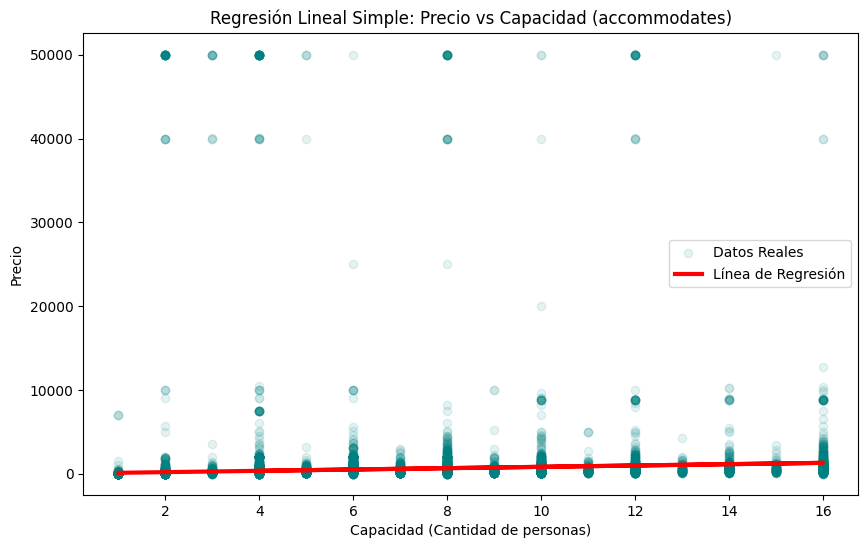

Resumen Modelo Simple (Entrenamiento):
R^2: 0.0084
RMSE: 2545.2255


In [52]:
# --- PASO 7: MODELO DE REGRESIÓN LINEAL SIMPLE (Univariado) ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Elegimos 'accommodates' (capacidad) por ser una de las que suele tener mayor correlación con el precio
X_train_simple = X_train[['accommodates']]
X_test_simple = X_test[['accommodates']]

# Crear y entrenar el modelo
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_simple, y_train)

# Hacer predicciones sobre el set de entrenamiento
predicciones_simple = modelo_simple.predict(X_train_simple)

# Graficar el modelo univariado
plt.figure(figsize=(10, 6))
plt.scatter(X_train_simple, y_train, color='teal', alpha=0.1, label='Datos Reales')
plt.plot(X_train_simple, predicciones_simple, color='red', linewidth=3, label='Línea de Regresión')
plt.title('Regresión Lineal Simple: Precio vs Capacidad (accommodates)')
plt.xlabel('Capacidad (Cantidad de personas)')
plt.ylabel('Precio')
plt.legend()
plt.show()

print("Resumen Modelo Simple (Entrenamiento):")
print(f"R^2: {r2_score(y_train, predicciones_simple):.4f}")
print(f"RMSE: {mean_squared_error(y_train, predicciones_simple) ** 0.5:.4f}")


### La línea de regresión (roja) muestra una pendiente ascendente. Esto confirma la hipótesis inicial: existe una correlación positiva directa entre ambas variables. A medida que aumenta la capacidad de la propiedad (accommodates), el precio esperado tiende a subir de forma constante.


### Al observar los datos reales (puntos celestes/verdes), se hace evidente que la varianza no es constante. En capacidades bajas (1 a 4 personas), los precios están sumamente concentrados en el rango inferior. Sin embargo, a medida que la capacidad supera las 6 personas, los precios se dispersan drásticamente en un rango vertical muy amplio (forma de embudo). Esto demuestra que para propiedades grandes, la capacidad por sí sola no es suficiente para dictar el precio; hay otros factores ocultos (como el lujo, la ubicación o amenidades) que este modelo simple no está capturando.

#### R² (0.0084): Este valor es extremadamente bajo. Nos indica que la variable accommodates (capacidad) por sí sola apenas logra explicar un 0.84% de la variabilidad de los precios de las casas. Esto significa que el 99.16% del precio depende de otros factores que no estamos incluyendo en este modelo (como ubicación, amenidades, etc.)

#### RMSE (2545.22): El Error Cuadrático Medio nos advierte que, en promedio, las predicciones de este modelo fallan por más de $2,545 dólares. Este es un margen de error inaceptable para el negocio de SmartStay Advisors y está fuertemente inflado por la incapacidad del modelo para ajustarse a los valores atípicos (propiedades de lujo)..

--- Resumen Modelo Múltiple (Entrenamiento) ---
R^2: 0.0027
RMSE: 2552.5260


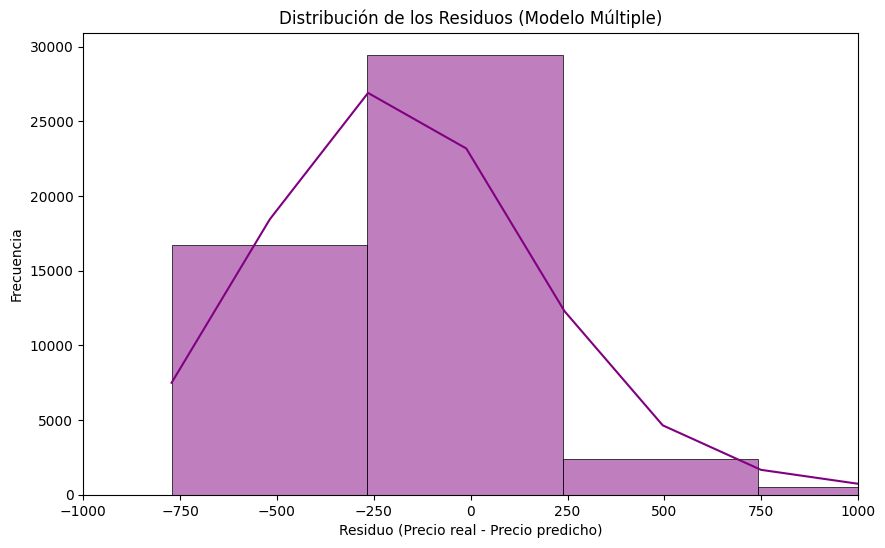

In [54]:
# --- PASO 8: MODELO DE REGRESIÓN LINEAL MÚLTIPLE ---
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

predicciones_multiple = modelo_multiple.predict(X_train)

print("--- Resumen Modelo Múltiple (Entrenamiento) ---")
print(f"R^2: {r2_score(y_train, predicciones_multiple):.4f}")
print(f"RMSE: {mean_squared_error(y_train, predicciones_multiple) ** 0.5:.4f}")

# Gráfica de Residuos
residuos = y_train - predicciones_multiple
plt.figure(figsize=(10, 6))
sns.histplot(residuos, bins=100, kde=True, color='purple')
plt.title('Distribución de los Residuos (Modelo Múltiple)')
plt.xlabel('Residuo (Precio real - Precio predicho)')
plt.ylabel('Frecuencia')
plt.xlim(-1000, 1000) # Limitamos el eje X para mejor visualización por valores atípicos
plt.show()

In [ ]:
# --- PASO 9: ANÁLISIS DE MULTICOLINEALIDAD (VIF) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculamos el VIF (Variance Inflation Factor)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
# Esto puede tardar unos segundos en ejecutarse
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]

print("--- Factor de Inflación de la Varianza (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False).head(10))
# Nota para tu Markdown: Valores de VIF mayores a 5 o 10 indican alta multicolinealidad.